In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamagarwal29/cow-lumpy-disease-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/cow-lumpy-disease-dataset


In [2]:
import os

new_dataset_path = path

# List contents
print(os.listdir(new_dataset_path))


['lumpycows', 'healthycows']


In [3]:
import os
import shutil

# Define target dataset path (must be in a writable area like /kaggle/working/)
target_dataset = "/kaggle/working/Livestock_Health_Dataset"

# Ensure destination folders exist
os.makedirs(os.path.join(target_dataset, "Healthy"), exist_ok=True)
os.makedirs(os.path.join(target_dataset, "Sick"), exist_ok=True)

# Mapping dataset folders to standard names
category_mapping = {
    "healthycows": "Healthy",
    "lumpycows": "Sick"
}

# Move (actually copy) images into the target dataset, avoiding overwrites
for src_folder, target_folder in category_mapping.items():
    src = os.path.join(new_dataset_path, src_folder)
    dst = os.path.join(target_dataset, target_folder)

    if os.path.exists(src):
        for file in os.listdir(src):
            src_file = os.path.join(src, file)
            dst_file = os.path.join(dst, file)

            # Avoid filename collision
            base, ext = os.path.splitext(file)
            counter = 1
            while os.path.exists(dst_file):
                dst_file = os.path.join(dst, f"{base}_{counter}{ext}")
                counter += 1

            shutil.copy2(src_file, dst_file)

print("Datasets copied successfully!")


Datasets copied successfully!


In [4]:
for category in ["Healthy", "Sick"]:
    count = len(os.listdir(os.path.join(target_dataset, category)))
    print(f"{category}: {count} images")


Healthy: 515 images
Sick: 421 images


Healthy: 515 images
Sick: 421 images


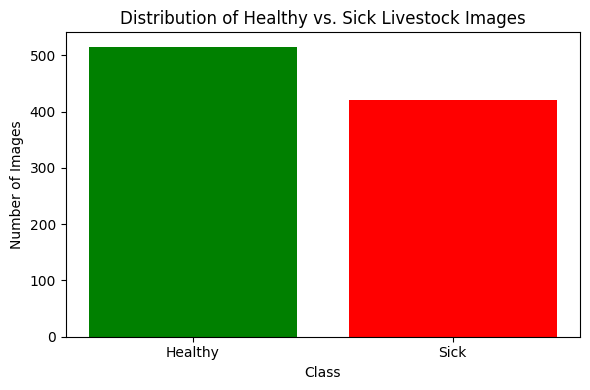

In [5]:
import os
import matplotlib.pyplot as plt


# Get categories (folder names like "Healthy", "Sick")
categories = ["Healthy", "Sick"]
counts = []

# Count the number of images in each category
for category in categories:
    category_path = os.path.join(target_dataset, category)
    count = len([file for file in os.listdir(category_path) if file.lower().endswith(('.png', '.jpg', '.jpeg'))])
    counts.append(count)
    print(f"{category}: {count} images")

# Plotting the class distribution
plt.figure(figsize=(6, 4))
plt.bar(categories, counts, color=["green", "red"])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Healthy vs. Sick Livestock Images")
plt.tight_layout()
plt.show()


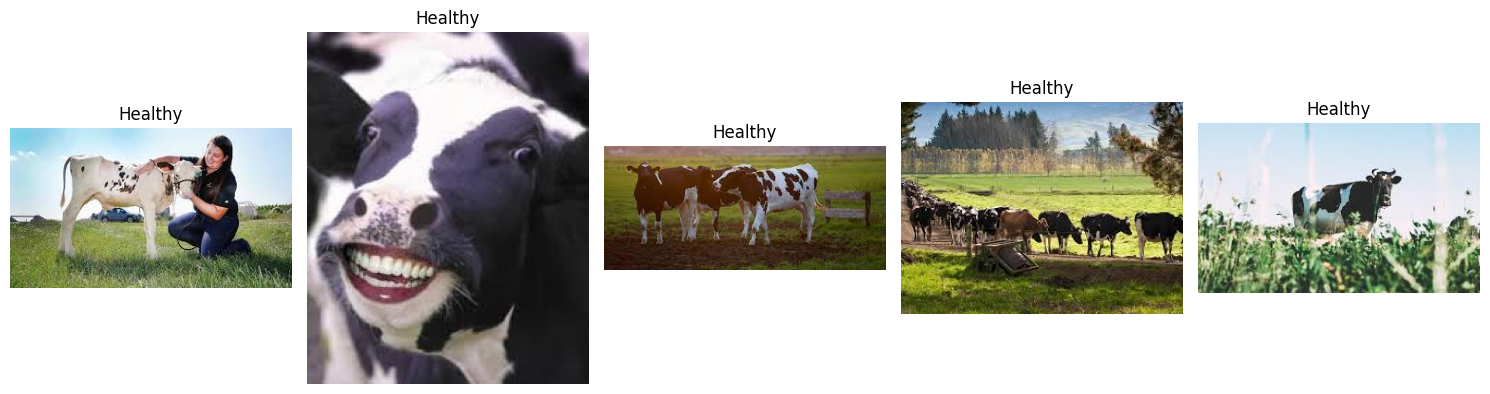

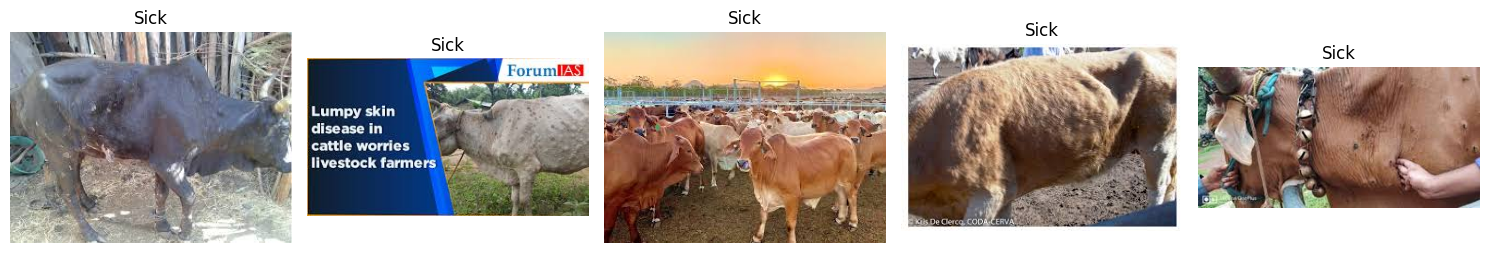

In [6]:
import os
import random
import cv2
from matplotlib import pyplot as plt

# Define dataset paths
dataset_path = "/kaggle/working/Livestock_Health_Dataset"  # Update with correct path

# Function to show sample images
def show_images(category, num_images=5):
    category_path = os.path.join(dataset_path, category)
    all_images = os.listdir(category_path)

    if len(all_images) == 0:
        print(f"No images found in {category}")
        return

    sample_count = min(num_images, len(all_images))
    images = random.sample(all_images, sample_count)

    plt.figure(figsize=(15, 5))
    for i, img_name in enumerate(images):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue  # Skip unreadable files

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        plt.subplot(1, sample_count, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(category)

    plt.tight_layout()
    plt.show()

# Show images from both categories
show_images("Healthy")
show_images("Sick")


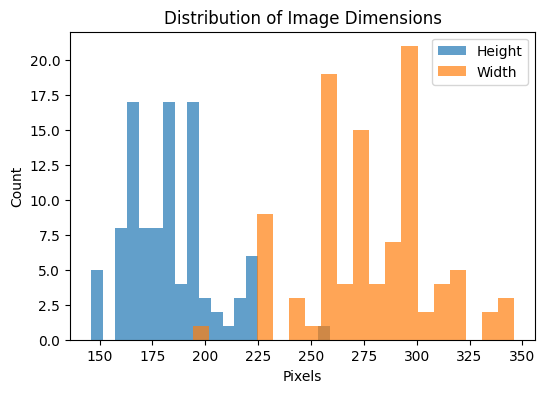

In [7]:
import numpy as np

image_shapes = []

for category in ["Healthy", "Sick"]:
    category_path = os.path.join(dataset_path, category)
    images = os.listdir(category_path)[:50]  # Check first 50 images

    for img_name in images:
        img = cv2.imread(os.path.join(category_path, img_name))
        if img is not None:
            image_shapes.append(img.shape[:2])  # Store (height, width)

# Convert to NumPy array for easier analysis
image_shapes = np.array(image_shapes)

# Plot distribution
plt.figure(figsize=(6, 4))
plt.hist(image_shapes[:, 0], bins=20, alpha=0.7, label="Height")
plt.hist(image_shapes[:, 1], bins=20, alpha=0.7, label="Width")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of Image Dimensions")
plt.show()


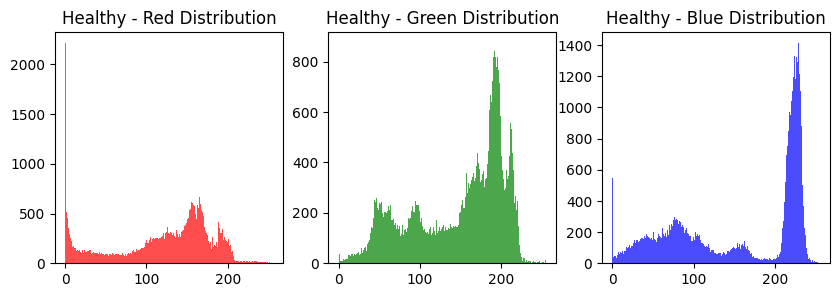

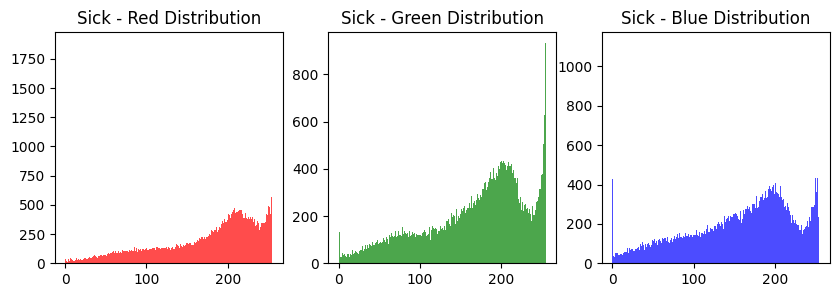

In [8]:
def plot_rgb_distribution(category):
    category_path = os.path.join(dataset_path, category)
    img_path = os.path.join(category_path, random.choice(os.listdir(category_path)))

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 3))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        plt.subplot(1, 3, i + 1)
        plt.hist(img_rgb[:, :, i].ravel(), bins=256, color=color.lower(), alpha=0.7)
        plt.title(f"{category} - {color} Distribution")

    plt.show()

# Show RGB distribution for both categories
plot_rgb_distribution("Healthy")
plot_rgb_distribution("Sick")


In [9]:
import cv2
import os
from tqdm import tqdm

# Define dataset paths
dataset_path = "/kaggle/working/Livestock_Health_Dataset"
output_path = "/path/to/Preprocessed_Livestock_Dataset"

# Standard size
IMG_SIZE = (224, 224)

# Resize images
for category in ["Healthy", "Sick"]:
    src_path = os.path.join(dataset_path, category)
    dst_path = os.path.join(output_path, category)
    os.makedirs(dst_path, exist_ok=True)

    for img_name in tqdm(os.listdir(src_path), desc=f"Resizing {category} images"):
        img_path = os.path.join(src_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.resize(img, IMG_SIZE)
            cv2.imwrite(os.path.join(dst_path, img_name), img)

print("✅ Images resized to 224x224 pixels.")


Resizing Sick images: 100%|██████████| 421/421 [00:00<00:00, 638.50it/s]

✅ Images resized to 224x224 pixels.


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a data generator with normalization
datagen = ImageDataGenerator(rescale=1.0/255)

# Load images from the directory
train_generator = datagen.flow_from_directory(
    output_path,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="binary"
)

print("✅ Images normalized (pixel values scaled to [0,1]).")


Found 936 images belonging to 2 classes.
✅ Images normalized (pixel values scaled to [0,1]).


In [11]:
# Augmentation configuration
augmented_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Load augmented images
train_augmented = augmented_datagen.flow_from_directory(
    output_path,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="binary"
)

print("✅ Data augmentation applied for Keras.")


Found 936 images belonging to 2 classes.
✅ Data augmentation applied for Keras.


In [12]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ensure the dataset exists
if not os.path.exists(output_path):
    print(f"Error: {output_path} does not exist. Check your dataset path.")
else:
    print(f"✅ Dataset found at: {output_path}")

# Define data generators
datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.15  # 15% for validation
)

# Load training set (85% -> further split into 70% train, 15% test)
train_generator = datagen.flow_from_directory(
    output_path,  # Make sure this path exists
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    output_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

print("✅ TensorFlow dataset split into training and validation.")


✅ Dataset found at: /path/to/Preprocessed_Livestock_Dataset
Found 796 images belonging to 2 classes.
Found 140 images belonging to 2 classes.
✅ TensorFlow dataset split into training and validation.


In [13]:
import os
import shutil
from sklearn.model_selection import train_test_split

# ✅ Correct dataset path
dataset_path = "/path/to/Preprocessed_Livestock_Dataset"
output_path = "/path/to/Split_Livestock_Dataset"

# Define categories
categories = ["Healthy", "Sick"]

# Define split ratios
test_size = 0.15  # 15% test set
val_size = 0.15   # 15% validation from remaining 85%

# Create train, val, and test folders
for folder in ["train", "val", "test"]:
    for category in categories:
        os.makedirs(os.path.join(output_path, folder, category), exist_ok=True)

# Split images
for category in categories:
    category_path = os.path.join(dataset_path, category)
    images = os.listdir(category_path)

    # Split into train+val and test
    train_val_imgs, test_imgs = train_test_split(images, test_size=test_size, random_state=42)

    # Split train and val
    train_imgs, val_imgs = train_test_split(train_val_imgs, test_size=val_size / (1 - test_size), random_state=42)

    # Move images
    for img_name in train_imgs:
        shutil.copy(os.path.join(category_path, img_name), os.path.join(output_path, "train", category, img_name))

    for img_name in val_imgs:
        shutil.copy(os.path.join(category_path, img_name), os.path.join(output_path, "val", category, img_name))

    for img_name in test_imgs:
        shutil.copy(os.path.join(category_path, img_name), os.path.join(output_path, "test", category, img_name))

print("✅ Dataset successfully split into Train, Validation, and Test sets!")


✅ Dataset successfully split into Train, Validation, and Test sets!


In [14]:
import os

# Define dataset split paths
split_dataset_path = "/path/to/Split_Livestock_Dataset"

# Define dataset categories
categories = ["Healthy", "Sick"]
splits = ["train", "val", "test"]

# Count images in each split
distribution = {}

for split in splits:
    distribution[split] = {}
    for category in categories:
        category_path = os.path.join(split_dataset_path, split, category)
        count = len(os.listdir(category_path))
        distribution[split][category] = count

# Print dataset distribution
for split, counts in distribution.items():
    print(f"📂 {split.upper()} SET:")
    for category, count in counts.items():
        print(f"   {category}: {count} images")
    print("-" * 30)


📂 TRAIN SET:
   Healthy: 359 images
   Sick: 293 images
------------------------------
📂 VAL SET:
   Healthy: 78 images
   Sick: 64 images
------------------------------
📂 TEST SET:
   Healthy: 78 images
   Sick: 64 images
------------------------------


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔧 Training base EfficientNetB0 (frozen layers)...
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 982ms/step - accuracy: 0.5100 - loss: 0.7162 - val_accuracy: 0.5500 - val_loss: 0.6999
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4928 - loss: 0.7200 - val_accuracy: 0.5500 - val_loss: 0.6904
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5269 - loss: 0.7110 - val_accuracy: 0.5500 - val_loss: 0.6904
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5207 - loss: 0.7018 - val_accuracy: 0.5500 - val_loss: 0.6884
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5060 - loss: 0.6966 - val_accuracy: 0.5500 - val_loss: 0.6905
🎯 Fine-tuning top EfficientNetB0 layers...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4718 - loss: 0.7633 - val_accuracy: 0.5500 - val_loss: 0.6904 - learning_rate: 1.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.4837 - loss: 0.7423 - val_accuracy: 0.5500 - val_loss: 0.6900 - learning_rate: 1.0000e-05
Epoch 3/15
25/25 ━━━━━━━━

✅ EfficientNetB0 fine-tuned model saved!


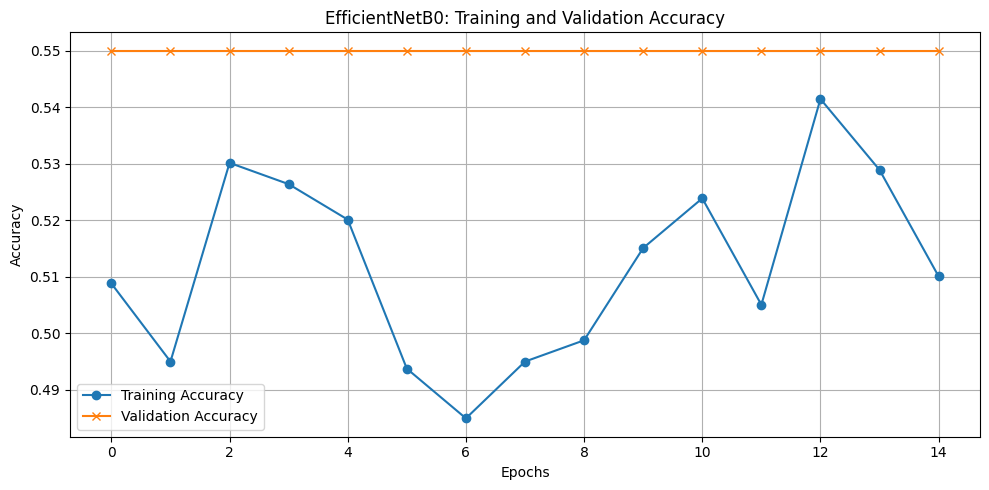

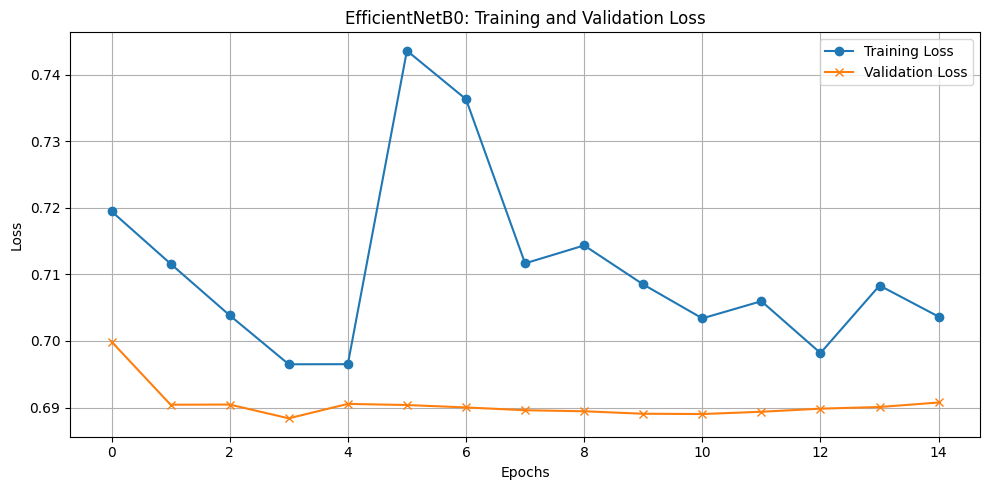

In [15]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import tensorflow as tf
import matplotlib.pyplot as plt

# Load base EfficientNetB0
efficientnet_base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
efficientnet_base.trainable = False  # Freeze base layers

# Add custom top layers
x = efficientnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
efficientnet_output = Dense(1, activation='sigmoid')(x)

# Build the full model
efficientnet_model = Model(inputs=efficientnet_base.input, outputs=efficientnet_output)

# Compile before base training
efficientnet_model.compile(optimizer=Adam(learning_rate=1e-4),
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

# Train with frozen base
print("🔧 Training base EfficientNetB0 (frozen layers)...")
efficientnet_history_base = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    verbose=1
)

# Unfreeze top 30 layers for fine-tuning
for layer in efficientnet_base.layers[-30:]:
    layer.trainable = True

# Recompile for fine-tuning
efficientnet_model.compile(optimizer=Adam(learning_rate=1e-5),
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

# Define callbacks
efficientnet_checkpoint = ModelCheckpoint("/kaggle/working/EfficientNetB0_FineTuned_Best.keras", save_best_only=True, monitor='val_loss')
efficientnet_reduce_lr = ReduceLROnPlateau(patience=2, factor=0.2, verbose=1)
efficientnet_early_stop = EarlyStopping(patience=4, restore_best_weights=True)

# Fine-tuning
print("🎯 Fine-tuning top EfficientNetB0 layers...")
efficientnet_history_finetune = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[efficientnet_checkpoint, efficientnet_reduce_lr, efficientnet_early_stop],
    verbose=1
)

# Save final models
efficientnet_model.save("/kaggle/working/EfficientNetB0_FineTuned_Model.h5")
efficientnet_model.save("/kaggle/working/EfficientNetB0_FineTuned_Model.keras")
print("✅ EfficientNetB0 fine-tuned model saved!")

# Combine histories
def combine_history(h1, h2):
    return {key: h1.history[key] + h2.history[key] for key in h1.history.keys()}

efficientnet_combined_history = combine_history(efficientnet_history_base, efficientnet_history_finetune)

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(efficientnet_combined_history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(efficientnet_combined_history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('EfficientNetB0: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(efficientnet_combined_history['loss'], label='Training Loss', marker='o')
plt.plot(efficientnet_combined_history['val_loss'], label='Validation Loss', marker='x')
plt.title('EfficientNetB0: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
🔧 Training base ResNet50 (frozen layers)...
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 617ms/step - accuracy: 0.4882 - loss: 0.8263 - val_accuracy: 0.5500 - val_loss: 0.7028
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.5157 - loss: 0.7751 - val_accuracy: 0.5500 - val_loss: 0.6800
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.4890 - loss: 0.7699 - val_accuracy: 0.5500 - val_loss: 0.6763
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.5001 - loss: 0.7496 - val_accuracy: 0.5500 - val_loss: 0.6686
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.5509 - loss: 0.7212 - val_accuracy: 0.5500 - val_loss: 0.6669
🎯 Fine-tuning top ResNet50 layers...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 721ms/step - accuracy: 0.5462 - loss: 0.7714 - val_accuracy: 0.5500 - val_loss: 0.6635 - learning_rate: 1.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.6315 - loss:

✅ ResNet50 fine-tuned model saved!


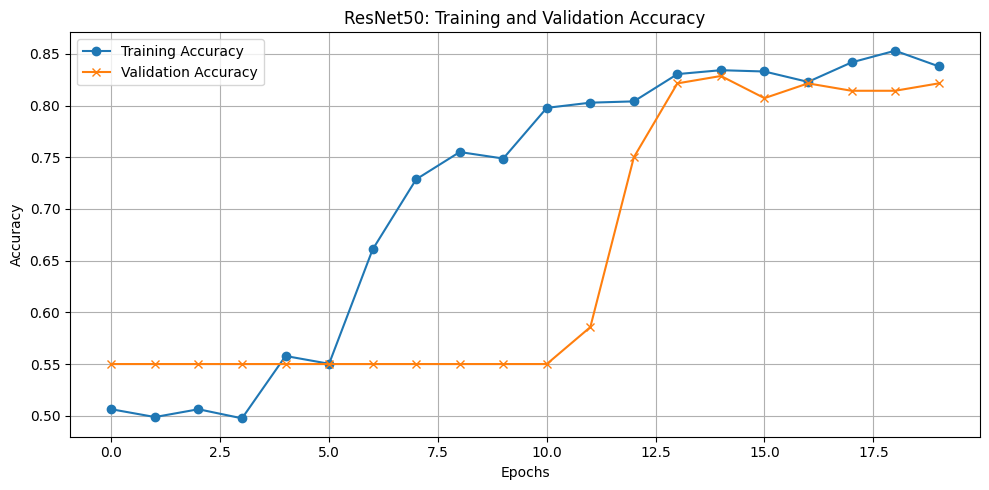

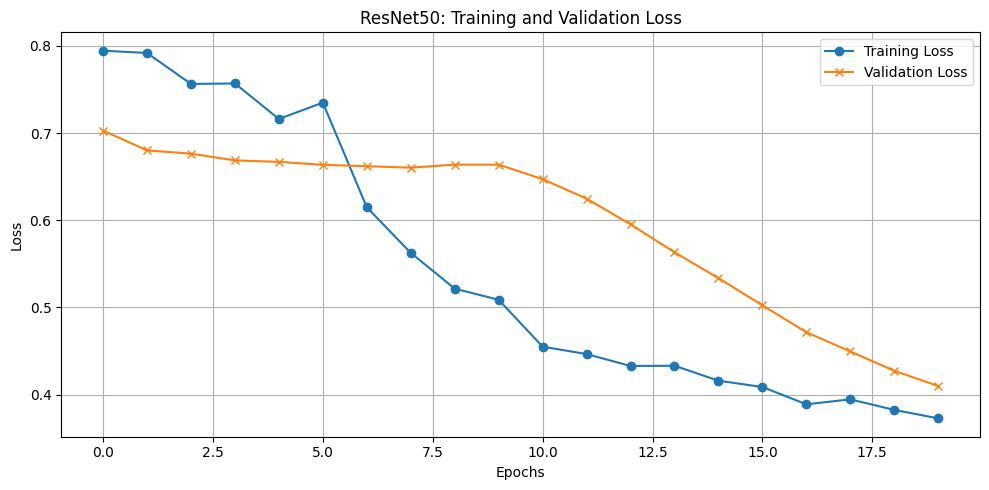

In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import tensorflow as tf
import matplotlib.pyplot as plt

# Load base ResNet50
resnet_base = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
resnet_base.trainable = False  # Freeze base layers

# Add custom top layers
x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
resnet_output = Dense(1, activation='sigmoid')(x)

# Build the full model
resnet_model = Model(inputs=resnet_base.input, outputs=resnet_output)

# Compile before base training
resnet_model.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

# Train with frozen base
print("🔧 Training base ResNet50 (frozen layers)...")
resnet_history_base = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    verbose=1
)

# Unfreeze top 30 layers for fine-tuning
for layer in resnet_base.layers[-30:]:
    layer.trainable = True

# Recompile for fine-tuning
resnet_model.compile(optimizer=Adam(learning_rate=1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

# Define callbacks
resnet_checkpoint = ModelCheckpoint("/kaggle/working/ResNet50_FineTuned_Best.keras", save_best_only=True, monitor='val_loss')
resnet_reduce_lr = ReduceLROnPlateau(patience=2, factor=0.2, verbose=1)
resnet_early_stop = EarlyStopping(patience=4, restore_best_weights=True)

# Fine-tuning
print("🎯 Fine-tuning top ResNet50 layers...")
resnet_history_finetune = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[resnet_checkpoint, resnet_reduce_lr, resnet_early_stop],
    verbose=1
)

# Save final models
resnet_model.save("/kaggle/working/ResNet50_FineTuned_Model.h5")
resnet_model.save("/kaggle/working/ResNet50_FineTuned_Model.keras")
print("✅ ResNet50 fine-tuned model saved!")

# Combine histories
def combine_history(h1, h2):
    return {key: h1.history[key] + h2.history[key] for key in h1.history.keys()}

resnet_combined_history = combine_history(resnet_history_base, resnet_history_finetune)

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(resnet_combined_history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(resnet_combined_history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('ResNet50: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(resnet_combined_history['loss'], label='Training Loss', marker='o')
plt.plot(resnet_combined_history['val_loss'], label='Validation Loss', marker='x')
plt.title('ResNet50: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-17-ecbd54c7976e>:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


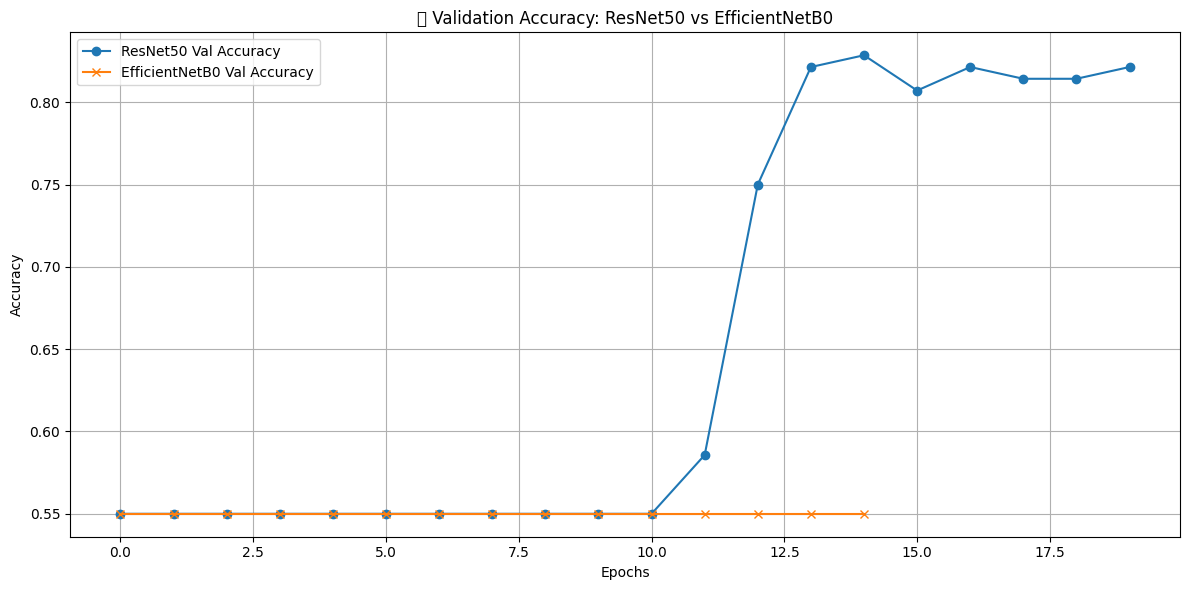

<ipython-input-17-ecbd54c7976e>:27: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


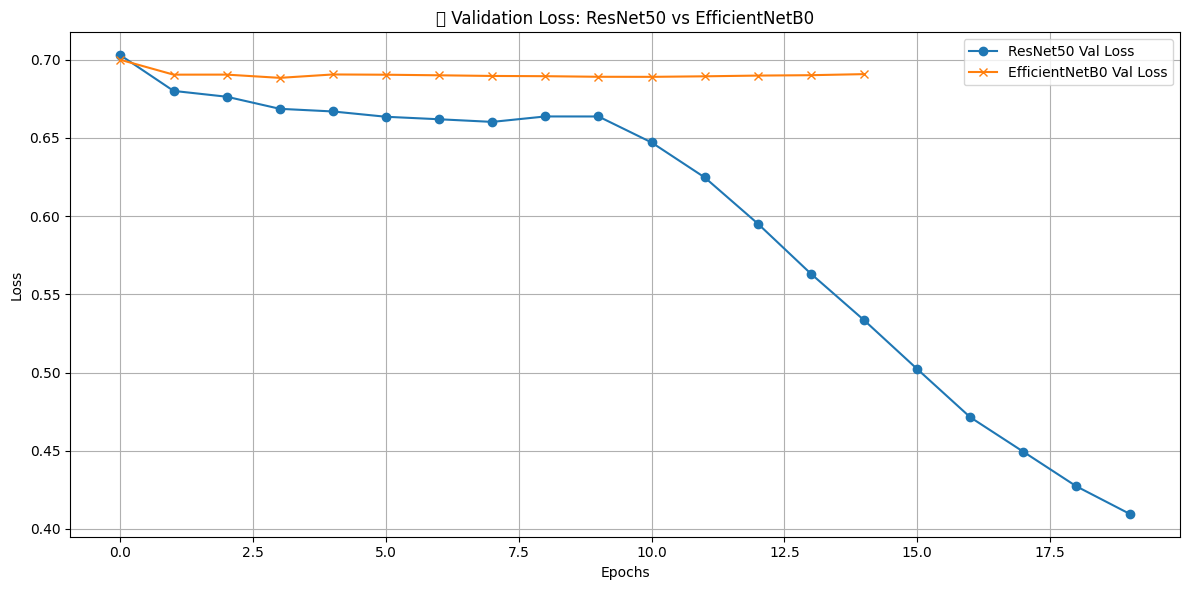

In [17]:
import matplotlib.pyplot as plt

epochs_resnet = range(len(resnet_combined_history['accuracy']))
epochs_efficientnet = range(len(efficientnet_combined_history['accuracy']))

# Accuracy Comparison
plt.figure(figsize=(12, 6))
plt.plot(epochs_resnet, resnet_combined_history['val_accuracy'], label='ResNet50 Val Accuracy', marker='o')
plt.plot(epochs_efficientnet, efficientnet_combined_history['val_accuracy'], label='EfficientNetB0 Val Accuracy', marker='x')
plt.title('📈 Validation Accuracy: ResNet50 vs EfficientNetB0')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Loss Comparison
plt.figure(figsize=(12, 6))
plt.plot(epochs_resnet, resnet_combined_history['val_loss'], label='ResNet50 Val Loss', marker='o')
plt.plot(epochs_efficientnet, efficientnet_combined_history['val_loss'], label='EfficientNetB0 Val Loss', marker='x')
plt.title('📉 Validation Loss: ResNet50 vs EfficientNetB0')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Base directory where your split datasets are stored
split_dataset_path = "/path/to/Split_Livestock_Dataset"  # Replace with your actual path

# Test directory
test_dir = os.path.join(split_dataset_path, "test")

# Define the test ImageDataGenerator (rescaling only)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create the test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 142 images belonging to 2 classes.


In [19]:
# Load the saved model
model = tf.keras.models.load_model("/kaggle/working/ResNet50_FineTuned_Best.keras")  # Update with the correct path

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"📊 Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 826ms/step - accuracy: 0.8221 - loss: 0.4253
📊 Test Accuracy: 84.51%
📉 Test Loss: 0.4069


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


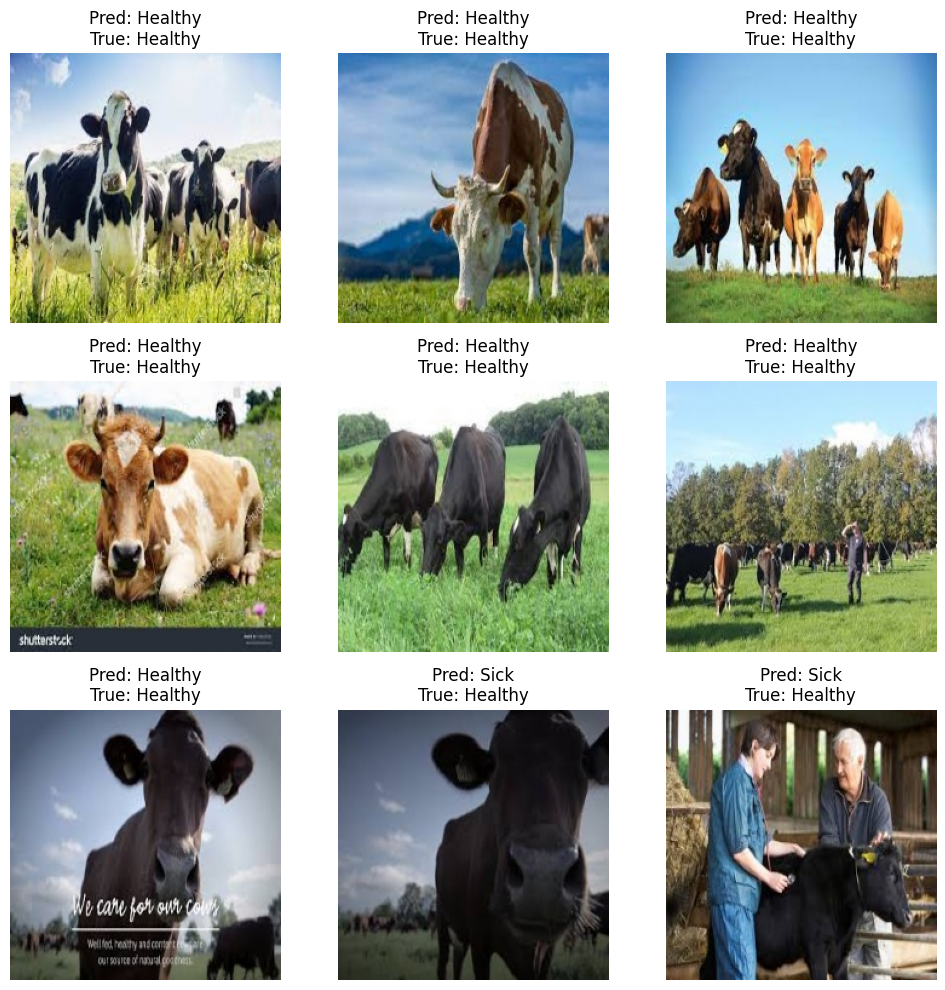

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Load a few test images
test_images, test_labels = next(test_generator)

# Make predictions
predictions = model.predict(test_images)
predicted_classes = (predictions > 0.4).astype("int").flatten()

# Plot images with predicted labels
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for img, pred, true_label, ax in zip(test_images, predicted_classes, test_labels, axes):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Pred: {class_labels[pred]}\nTrue: {class_labels[int(true_label)]}")

plt.tight_layout()
plt.show()


In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the saved fine-tuned model (if not already loaded)
model = tf.keras.models.load_model("/kaggle/working/ResNet50_FineTuned_Best.keras")  # or .h5

# Label mapping
class_names = ["Healthy", "Sick"]

def predict_health(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Normalize to [0,1]
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict
    prediction = model.predict(img_array)[0][0]
    label = class_names[int(prediction > 0.5)]
    confidence = prediction if label == "Sick" else 1 - prediction

    print(f"📷 Prediction: {label} ({confidence * 100:.2f}% confidence)")
    return label


In [22]:
predict_health("/kaggle/working/Livestock_Health_Dataset/Healthy/imgs484.jpg")
predict_health("/kaggle/working/Livestock_Health_Dataset/Sick/img1255.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
📷 Prediction: Healthy (78.08% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
📷 Prediction: Sick (66.08% confidence)


'Sick'